# 1. Data
Obtained from DATASETS (muratkoklu.com) and used in M. Koklu, R. Kursun, Y.S. Taspinar, and I. Cinar, "Classification of Date Fruits into Genetic Varieties Using Image Analysis," Mathematical Problems in Engineering, Vol.2021, Article ID: 4793293 (2021).

**Problem Statement:**
In food production it is important to properly label ingredients for both health and business reasons. However, sometimes mistakes are made and there is room for improvement in food labeling practices. A number of different types of dates are grown around the world, and it takes expertise to correctly identify the variety. Your job as a machine learning developer is to create a model that can identify the type of date from external features such as colour, length, diameter and shape factors which have been determined by a computer vision model.
## 1.1 Load Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras.optimizers import Adam, SGD


df = pd.read_csv('Date_Fruit_Datasets.csv')
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-5.919126e+10,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-3.423307e+10,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-9.394835e+10,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-3.207431e+10,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-3.998097e+10,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


## 1.2 Summarize the Data


In [2]:
df


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.9080,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-5.919126e+10,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.1440,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-3.423307e+10,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.3940,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-9.394835e+10,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.2100,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-3.207431e+10,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.3540,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-3.998097e+10,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
893,255403,1925.3650,691.8453,477.1796,0.7241,570.2536,0.9785,261028,0.7269,1.4499,...,2.2423,2.3704,2.7202,-2.529642e+10,-19168882688,-18473392128,49.0869,43.0422,42.4153,SOGAY
894,365924,2664.8230,855.4633,551.5447,0.7644,682.5752,0.9466,386566,0.6695,1.5510,...,3.4109,3.5805,3.9910,-3.160522e+10,-21945366528,-19277905920,46.8086,39.1046,36.5502,SOGAY
895,254330,1926.7360,747.4943,435.6219,0.8126,569.0545,0.9925,256255,0.7240,1.7159,...,2.2759,2.5090,2.6951,-2.224277e+10,-19594921984,-17592152064,44.1325,40.7986,40.9769,SOGAY
896,238955,1906.2679,716.6485,441.8297,0.7873,551.5859,0.9604,248795,0.6954,1.6220,...,2.6769,2.6874,2.7991,-2.604860e+10,-21299822592,-19809978368,51.2267,45.7162,45.6260,SOGAY


In [3]:
df.describe()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,SkewRB,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB
count,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,898.000000,...,898.000000,898.000000,898.000000,898.000000,8.980000e+02,8.980000e+02,8.980000e+02,898.000000,898.000000,898.000000
mean,298295.207127,2057.660953,750.811994,495.872785,0.737468,604.577938,0.981840,303845.592428,0.736267,2.131102,...,0.250518,4.247845,5.110894,3.780928,-3.185021e+10,-2.901860e+10,-2.771876e+10,50.082888,48.805681,48.098393
std,107245.205337,410.012459,144.059326,114.268917,0.088727,119.593888,0.018157,108815.656947,0.053745,17.820778,...,0.632918,2.892357,3.745463,2.049831,2.037241e+10,1.712952e+10,1.484137e+10,16.063125,14.125911,10.813862
min,1987.000000,911.828000,336.722700,2.283200,0.344800,50.298400,0.836600,2257.000000,0.512300,1.065300,...,-1.029100,1.708200,1.607600,1.767200,-1.091220e+11,-9.261697e+10,-8.747177e+10,15.191100,20.524700,22.130000
25%,206948.000000,1726.091500,641.068650,404.684375,0.685625,513.317075,0.978825,210022.750000,0.705875,1.373725,...,-0.196950,2.536625,2.508850,2.577275,-4.429444e+10,-3.894638e+10,-3.564534e+10,38.224425,38.654525,39.250725
50%,319833.000000,2196.345450,791.363400,495.054850,0.754700,638.140950,0.987300,327207.000000,0.746950,1.524150,...,0.135550,3.069800,3.127800,3.080700,-2.826156e+10,-2.620990e+10,-2.392928e+10,53.841300,50.337800,49.614100
75%,382573.000000,2389.716575,858.633750,589.031700,0.802150,697.930525,0.991800,388804.000000,0.775850,1.674750,...,0.593950,4.449850,7.320400,4.283125,-1.460482e+10,-1.433105e+10,-1.660367e+10,63.063350,59.573600,56.666675
max,546063.000000,2811.997100,1222.723000,766.453600,1.000000,833.827900,0.997400,552598.000000,0.856200,535.525700,...,3.092300,26.171100,26.736700,32.249500,-1.627316e+08,-5.627727e+08,-4.370435e+08,79.828900,83.064900,74.104600


##  Observations:
-
-
-
-


## 1.3  Checking the Datatype and Missing values

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 898 entries, 0 to 897
Data columns (total 35 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           898 non-null    int64  
 1   PERIMETER      898 non-null    float64
 2   MAJOR_AXIS     898 non-null    float64
 3   MINOR_AXIS     898 non-null    float64
 4   ECCENTRICITY   898 non-null    float64
 5   EQDIASQ        898 non-null    float64
 6   SOLIDITY       898 non-null    float64
 7   CONVEX_AREA    898 non-null    int64  
 8   EXTENT         898 non-null    float64
 9   ASPECT_RATIO   898 non-null    float64
 10  ROUNDNESS      898 non-null    float64
 11  COMPACTNESS    898 non-null    float64
 12  SHAPEFACTOR_1  898 non-null    float64
 13  SHAPEFACTOR_2  898 non-null    float64
 14  SHAPEFACTOR_3  898 non-null    float64
 15  SHAPEFACTOR_4  898 non-null    float64
 16  MeanRR         898 non-null    float64
 17  MeanRG         898 non-null    float64
 18  MeanRB    

In [5]:
df.isnull().sum()

AREA             0
PERIMETER        0
MAJOR_AXIS       0
MINOR_AXIS       0
ECCENTRICITY     0
EQDIASQ          0
SOLIDITY         0
CONVEX_AREA      0
EXTENT           0
ASPECT_RATIO     0
ROUNDNESS        0
COMPACTNESS      0
SHAPEFACTOR_1    0
SHAPEFACTOR_2    0
SHAPEFACTOR_3    0
SHAPEFACTOR_4    0
MeanRR           0
MeanRG           0
MeanRB           0
StdDevRR         0
StdDevRG         0
StdDevRB         0
SkewRR           0
SkewRG           0
SkewRB           0
KurtosisRR       0
KurtosisRG       0
KurtosisRB       0
EntropyRR        0
EntropyRG        0
EntropyRB        0
ALLdaub4RR       0
ALLdaub4RG       0
ALLdaub4RB       0
Class            0
dtype: int64

- There are no missing or null values
- Most of the columns are Float and the age is integer.

In [6]:
df.duplicated
df.duplicated().sum()

0

- There are no duplicates in our dataset!

## 1.4 Bar Plot Checking for Balance

Text(0.5, 1.0, 'Distribution of Date Fruit Classes')

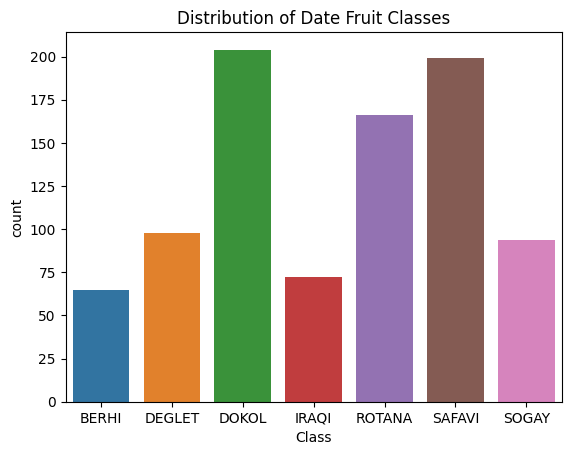

In [7]:
# Bar plot goes here
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title('Distribution of Date Fruit Classes')

### 1.4.1 Comments on Balance
- The fruit classes are not balanced, most of the dataset fruits are either DOKOL, SAFAVI or ROTANA.
- The rest of the classes don't have as much instances, making the dataset unbalanced.


## 1.5 Separating and Scaling Data
- Saving the class column (the label y)
- Using the other columns (the features X) as separated features.
- Reshaping the labels to a 2D array.
- Scaling and splitting the data

In [8]:
from sklearn.preprocessing import LabelEncoder
features = df.drop(columns=['Class']).values
labels = df[['Class']].values

le = LabelEncoder()
labels = le.fit_transform(labels) # Convert into integers
labels = labels.reshape(-1, 1) # Convert into 2D array
print(f"\nReshaped labels shape: {labels.shape}")
labels


Reshaped labels shape: (898, 1)


c:\Users\danie\anaconda3\envs\dl_39\lib\site-packages\sklearn\preprocessing\_label.py:115: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([[0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

In [9]:
# Determine which number has been assigned to each type of date and record this information in markdown.
label_mapping = {class_name: idx for idx, class_name in enumerate(le.classes_)}
label_mapping

{'BERHI': 0,
 'DEGLET': 1,
 'DOKOL': 2,
 'IRAQI': 3,
 'ROTANA': 4,
 'SAFAVI': 5,
 'SOGAY': 6}

The classes were organized alphabetically and then assigned a 0-6 index as shown in the dictionary. 

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
# Scaling the features
x_scaler = StandardScaler()
x_scaled = x_scaler.fit_transform(features)

# Splitting the dataset using 80% train and 10% validation and 10% test
X_train, X_temp, y_train, y_temp = train_test_split(
    x_scaled, labels, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [11]:
X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((718, 34), (718, 1), (90, 34), (90, 1), (90, 34), (90, 1))

# 2. Modeling

Use tf.keras.Sequential to create a fully connected artificial neural network with at least two hidden layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

**Strategy**

Our approach is going to be focused on trying different hyperparameters combinations, departing from a baseline model that uses only 2 hidden layers and an input layer equallt sized to the number of inputs.

**Limiting the number of epochs** 

In addition to testing different combinations of hyperparameters, we are also trying to use early stoppers to avoid overfitting, trying to look for a "sweet spot" of combinations that deliver the best possible results.

## 2.1 Model 1: Baseline

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model1 = Sequential()

model1.add(Dense(units = 32, activation = 'relu', input_shape=(34,)))
model1.add(Dense(units = 64, activation = 'relu'))
model1.add(Dense(units = 7, activation = 'softmax'))  # 7 classes
model1.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                1120      
                                                                 
 dense_1 (Dense)             (None, 64)                2112      
                                                                 
 dense_2 (Dense)             (None, 7)                 455       
                                                                 
Total params: 3,687
Trainable params: 3,687
Non-trainable params: 0
_________________________________________________________________


Compile the model with a choice of optimizer and loss function, and the set the metrics argument equal to ['accuracy'].


In [13]:
optimizer = Adam(learning_rate=0.001)
model1.compile(optimizer=optimizer, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])

Train the model and record the training accuracy. Find the validation accuracy and confusion matrix.


In [14]:

history = model1.fit(
    X_train, y_train, 
    epochs=200,
    validation_data=(X_val, y_val), 
    verbose=1
)

# Access validation accuracy from history
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Epoch 1/200
23/23 [==============================] - 1s 18ms/step - loss: 1.7021 - accuracy: 0.3774 - val_loss: 1.2827 - val_accuracy: 0.7222
Epoch 2/200
23/23 [==============================] - 0s 4ms/step - loss: 1.1132 - accuracy: 0.6783 - val_loss: 0.7867 - val_accuracy: 0.7667
Epoch 3/200
23/23 [==============================] - 0s 4ms/step - loss: 0.7741 - accuracy: 0.7382 - val_loss: 0.5569 - val_accuracy: 0.8333
Epoch 4/200
23/23 [==============================] - 0s 4ms/step - loss: 0.5897 - accuracy: 0.7855 - val_loss: 0.4439 - val_accuracy: 0.8778
Epoch 5/200
23/23 [==============================] - 0s 4ms/step - loss: 0.4858 - accuracy: 0.8245 - val_loss: 0.3730 - val_accuracy: 0.9111
Epoch 6/200
23/23 [==============================] - 0s 4ms/step - loss: 0.4175 - accuracy: 0.8510 - val_loss: 0.3327 - val_accuracy: 0.9000
Epoch 7/200
23/23 [==============================] - 0s 6ms/step - loss: 0.3687 - accuracy: 0.8663 - val_loss: 0.2960 - val_accuracy: 0.9444
Epoch 8/200


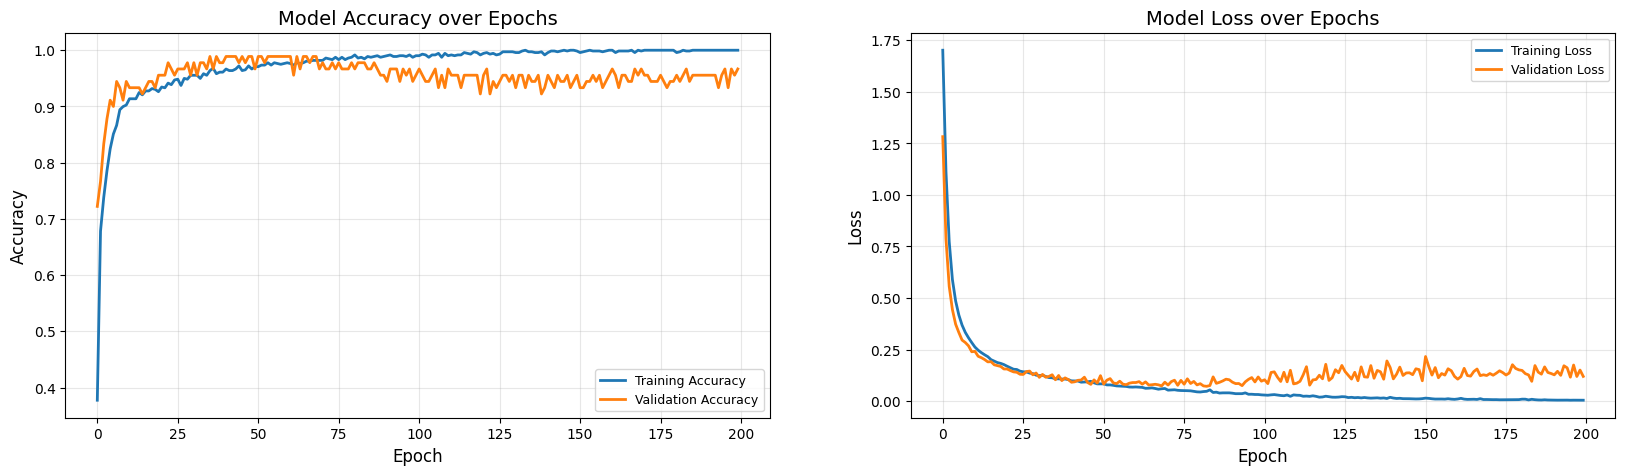

In [15]:
# Plotting training and validation metrics
fig, axes = plt.subplots(1, 2, figsize=(20, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy over Epochs', fontsize=14)
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss over Epochs', fontsize=14)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

- Neatly present the description of each model tried along with the training and validation accuracies, and the confusion matrix.

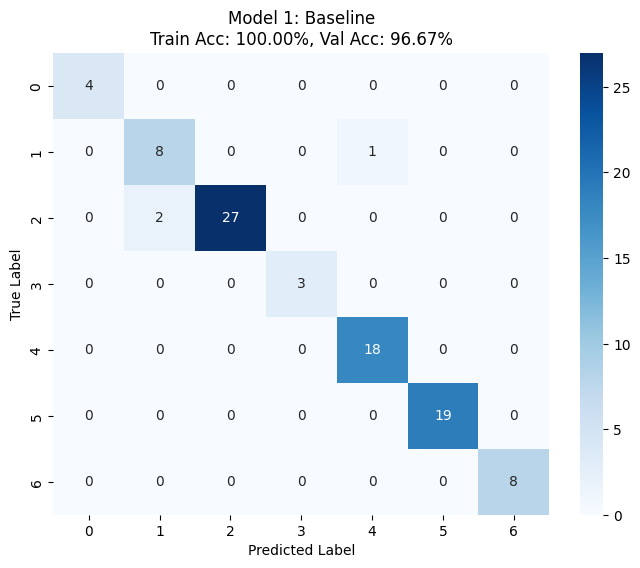

In [16]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred1 = model1.predict(X_val, verbose=0).argmax(axis=1)
cm1 = confusion_matrix(y_val, y_pred1)

plt.figure(figsize=(8, 6))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
plt.title('Model 1: Baseline\nTrain Acc: {:.2f}%, Val Acc: {:.2f}%'.format(final_train_acc*100, final_val_acc*100))
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Return to the above steps to try at least five different choices of hyperparameters (including dimensions, activation functions, number of layers, optimizer, loss function, etc.)

#### Function Definition
To properly address this requirement, we decided to create a function that executes all the code above, and provides a graphical evolution of both the training and validation accuracies, as well as the confusion matrix so we can test it to 5 different model proposal, using different hyperparameters, and then analyze their effect on the final results.

In [17]:
def model_analysis(model_x, X_train, y_train, X_val, y_val, epochs_x, optimizer_x = 'adam'):
    model_x.summary()
    model_x.compile(optimizer=optimizer_x, loss = 'sparse_categorical_crossentropy', metrics=['accuracy'])
    # Fitting the model
    history = model_x.fit(
    X_train, y_train, 
    epochs=epochs_x,
    validation_data=(X_val, y_val), 
    verbose=1
    )
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    # Printing final accuracies
    print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
    print(f"Final Validation Accuracy: {final_val_acc:.4f}")
    # Plotting training and validation metrics
    fig, axes = plt.subplots(1, 2, figsize=(20, 5))

    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Accuracy', fontsize=12)
    axes[0].set_title('Model Accuracy over Epochs', fontsize=14)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Loss plot
    axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Model Loss over Epochs', fontsize=14)
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)
    # Confusion Matrix
    y_pred1 = model_x.predict(X_val, verbose=0).argmax(axis=1)
    cm1 = confusion_matrix(y_val, y_pred1)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues')
    plt.title('Model 1: Baseline\nTrain Acc: {:.2f}%, Val Acc: {:.2f}%'.format(final_train_acc*100, final_val_acc*100))
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               4480      
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 7)                 455       
                                                                 
Total params: 13,191
Trainable params: 13,191
Non-trainable params: 0
_________________________________________________________________
Epoch 1/200
23/23 [==============================] - 0s 10ms/step - loss: 1.8473 - accuracy: 0.1950 - val_loss: 1.7076 - val_accuracy: 0.3111
Epoch 2/200
23/23 [==============================] - 0s 3ms/step - loss: 1.6352 - accuracy: 0.4791 - val_loss: 1.4972 - val_accuracy: 0.5111
Epoch 3/200
23/23 [============

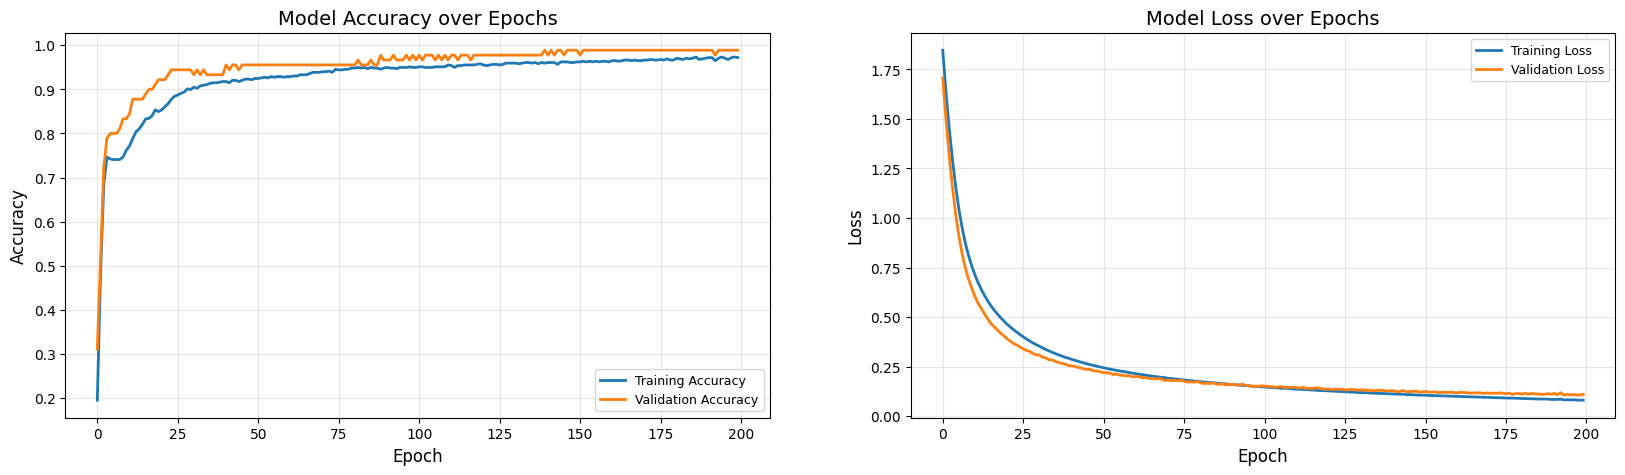

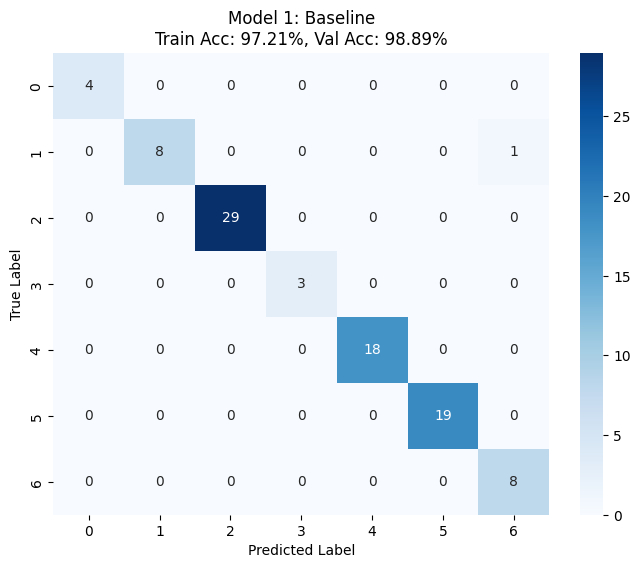

In [18]:
model2 = Sequential([
    Dense(128, activation='relu', input_shape=(34,)),
    Dense(64, activation='relu'),
    Dense(7, activation='softmax')
])
optimizer2 = Adam(learning_rate=0.0001)
model_analysis(model2, X_train, y_train, X_val, y_val, epochs_x=200, optimizer_x=optimizer2)

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 128)               4480      
                                                                 
 dense_7 (Dense)             (None, 64)                8256      
                                                                 
 dense_8 (Dense)             (None, 32)                2080      
                                                                 
 dense_9 (Dense)             (None, 16)                528       
                                                                 
 dense_10 (Dense)            (None, 7)                 119       
                                                                 
Total params: 15,463
Trainable params: 15,463
Non-trainable params: 0
_________________________________________________________________
Epoch 1/200
23/23 [==============================]

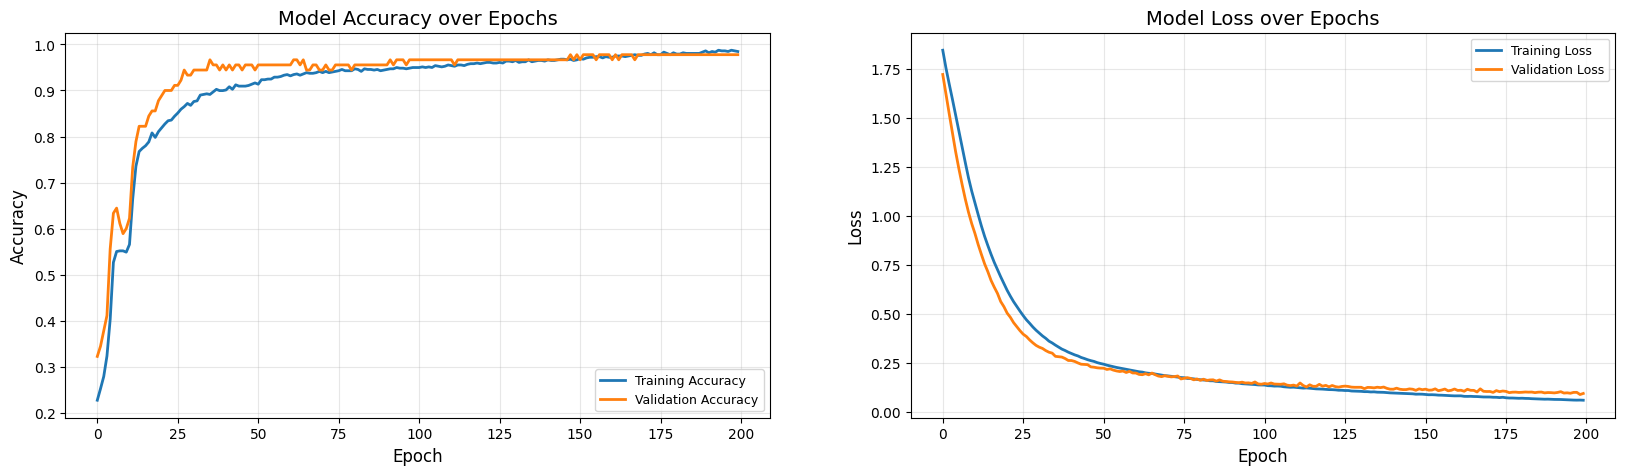

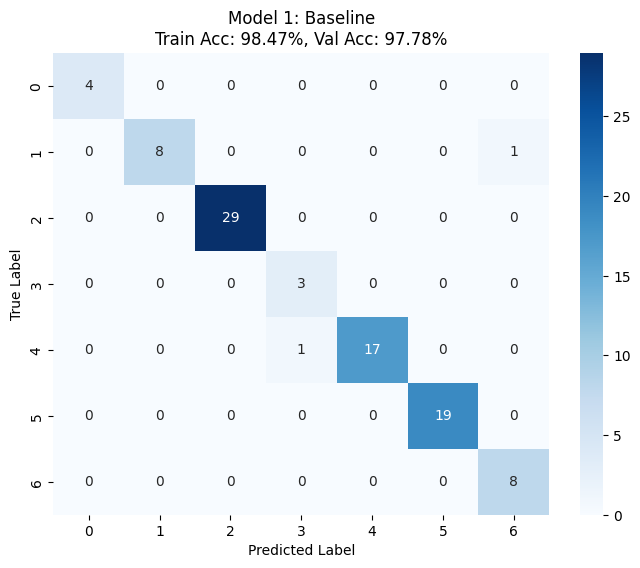

In [20]:
model3 = Sequential([ # Best around epoch 167
    Dense(128, activation='relu', input_shape=(34,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(7, activation='softmax')
])
optimizer3 = Adam(learning_rate=0.0001)
model_analysis(model3, X_train, y_train, X_val, y_val, epochs_x=200, optimizer_x=optimizer3)

- Calculate predictions

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 34)                1190      
                                                                 
 dense_12 (Dense)            (None, 64)                2240      
                                                                 
 dense_13 (Dense)            (None, 7)                 455       
                                                                 
Total params: 3,885
Trainable params: 3,885
Non-trainable params: 0
_________________________________________________________________
Epoch 1/200
23/23 [==============================] - 1s 18ms/step - loss: 2.0046 - accuracy: 0.0724 - val_loss: 1.9099 - val_accuracy: 0.1556
Epoch 2/200
23/23 [==============================] - 0s 7ms/step - loss: 1.8124 - accuracy: 0.2270 - val_loss: 1.7143 - val_accuracy: 0.3444
Epoch 3/200
23/23 [==============

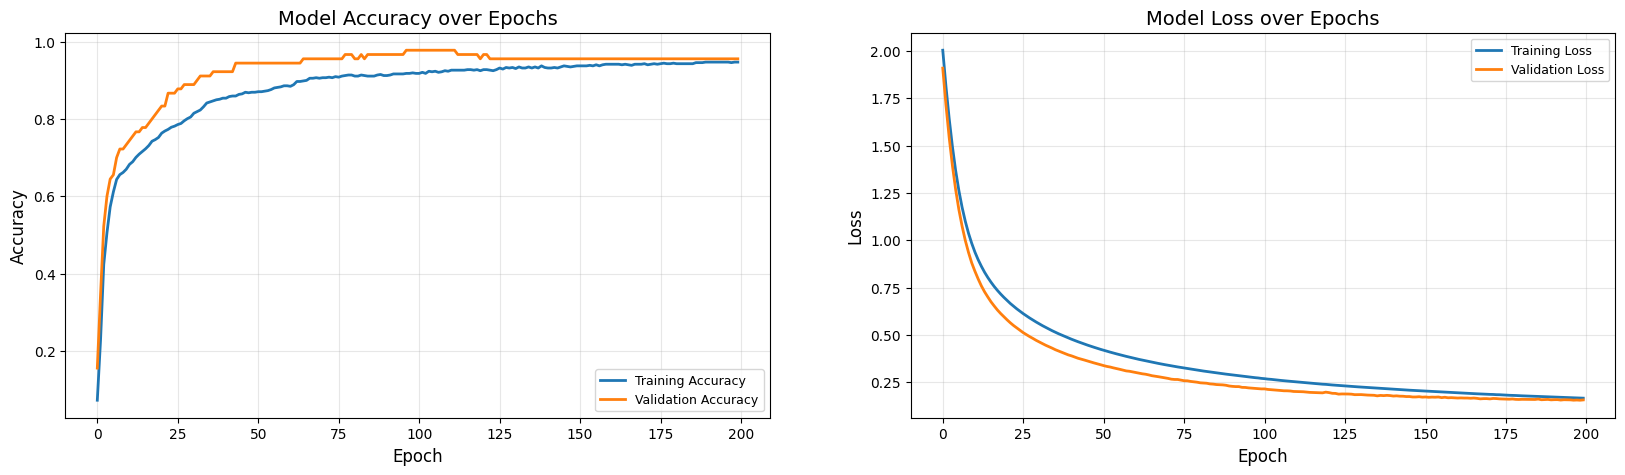

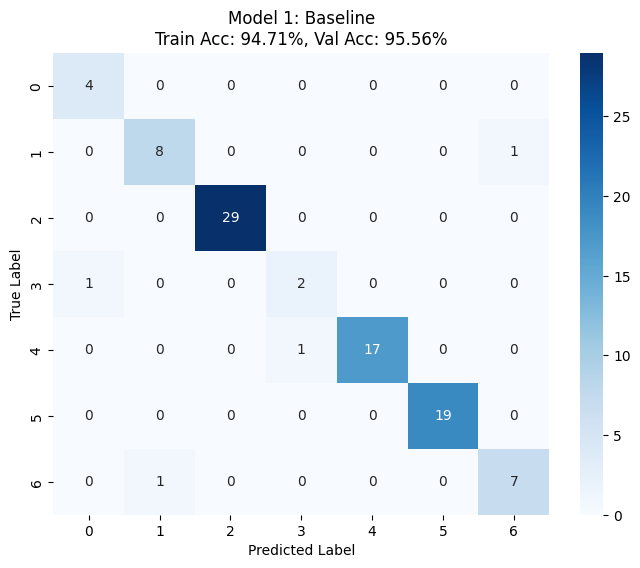

In [21]:
model4 = Sequential([
    Dense(34, activation='tanh', input_shape=(34,)),
    Dense(64, activation='tanh'),
    Dense(7, activation='softmax')
])
optimizer4 = Adam(learning_rate=0.0001)
model_analysis(model4, X_train, y_train, X_val, y_val, epochs_x=200, optimizer_x=optimizer4)

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   


 dense_14 (Dense)            (None, 34)                1190      
                                                                 
 dense_15 (Dense)            (None, 64)                2240      
                                                                 
 dense_16 (Dense)            (None, 7)                 455       
                                                                 
Total params: 3,885
Trainable params: 3,885
Non-trainable params: 0
_________________________________________________________________
Epoch 1/300
23/23 [==============================] - 1s 21ms/step - loss: 2.1402 - accuracy: 0.0794 - val_loss: 2.1597 - val_accuracy: 0.0667
Epoch 2/300
23/23 [==============================] - 0s 8ms/step - loss: 2.0621 - accuracy: 0.0877 - val_loss: 2.0721 - val_accuracy: 0.0667
Epoch 3/300
23/23 [==============================] - 0s 9ms/step - loss: 1.9914 - accuracy: 0.0975 - val_loss: 1.9904 - val_accuracy: 0.0556
Epoch 4/300
23/23 [===========================

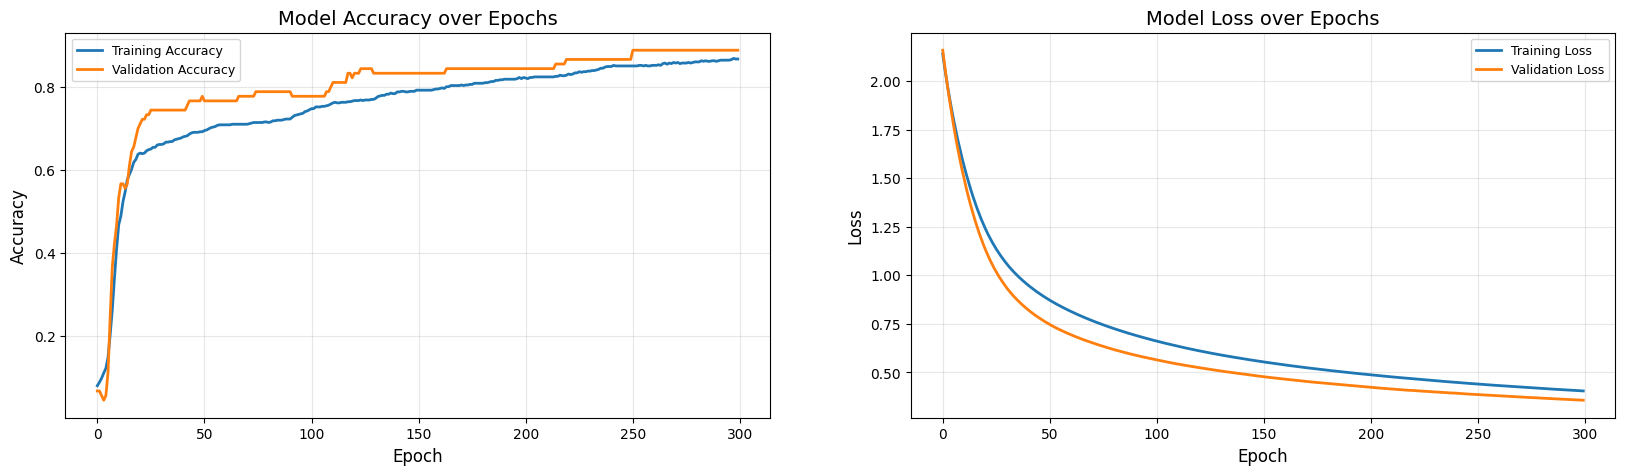

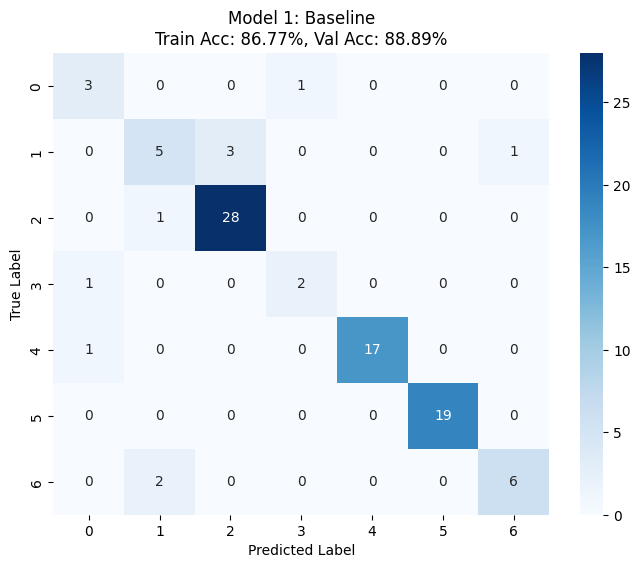

In [22]:
model5 = Sequential([
    Dense(34, activation='relu', input_shape=(34,)),
    Dense(64, activation='relu'),
    Dense(7, activation='softmax')
])
optimizer5 = SGD(learning_rate=0.001)
model_analysis(model5, X_train, y_train, X_val, y_val, epochs_x=300, optimizer_x=optimizer5)

# 3. Conclusion
## 3.1 Best model selection